In [1]:
# Notebook-friendly utilities to build a nested dictionary from training_results.json
# Shape: summary[P][kappa_str][exp_id] = {"train_mse": ..., "test_mse": ..., "m_S": ...}

from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, Any, List

def _fmt_float_key(x: float, ndigits: int = 8) -> str:
    """Format float for stable dict keys (matches your resume precision)."""
    return f"{float(x):.{ndigits}f}"

def build_summary_mse(results_path: str | Path,
                      kappa_ndigits: int = 8
                     ) -> Dict[int, Dict[str, Dict[int, Dict[str, float]]]]:
    """
    Build nested dict:
        summary[P][kappa_str][exp_id] = {
            "train_mse": float,
            "test_mse": float,
            "m_S": float,           # from final_eval_mS, fallback to init_eval_mS
        }

    If multiple entries exist for the same (P, kappa_0, exp_id),
    keeps the one with the largest 'epochs_run'.
    """
    path = Path(results_path)
    with open(path, "r") as f:
        data = json.load(f)

    if not isinstance(data, list):
        raise ValueError("Expected the results file to contain a JSON list of records.")

    summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]] = {}
    best_epochs: Dict[tuple, int] = {}

    for rec in data:
        # Required indexing keys
        P = int(rec["P"])
        kappa_key = _fmt_float_key(rec["kappa_0"], ndigits=kappa_ndigits)
        exp_id = int(rec["exp_id"])
        epochs_run = int(rec.get("epochs_run", -1))

        # Metrics we keep (MSE + m_S)
        train_mse = float(rec["train_mse"])
        test_mse  = float(rec["test_mse"])
        if "final_eval_mS" in rec:
            m_s = float(rec["final_eval_mS"])
        elif "init_eval_mS" in rec:
            m_s = float(rec["init_eval_mS"])
        else:
            # Shouldn't happen with your logs, but guard anyway
            m_s = float("nan")

        key = (P, kappa_key, exp_id)
        if key in best_epochs and epochs_run <= best_epochs[key]:
            # Existing entry is as complete or more complete; skip
            continue

        summary.setdefault(P, {}).setdefault(kappa_key, {})[exp_id] = {
            "train_mse": train_mse,
            "test_mse": test_mse,
            "m_S": m_s,
        }
        best_epochs[key] = epochs_run

    return summary

def summary_to_rows(summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]]
                   ) -> List[Dict[str, Any]]:
    """
    Flatten to a list of rows for quick DataFrame creation:
    [
      {"P": ..., "kappa_0": ..., "exp_id": ..., "train_mse": ..., "test_mse": ..., "m_S": ...},
      ...
    ]
    """
    rows: List[Dict[str, Any]] = []
    for P, kappas in summary.items():
        for kappa_str, exps in kappas.items():
            for exp_id, metrics in exps.items():
                rows.append({
                    "P": int(P),
                    "kappa_0": float(kappa_str),
                    "exp_id": int(exp_id),
                    **metrics,
                })
    return rows

# ---- Example usage in a notebook ----
results_path = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/training_results.json"
summary = build_summary_mse(results_path)
  # -> {'train_mse': ..., 'test_mse': ..., 'm_S': ...}
#
# # If you want a DataFrame:
# import pandas as pd
# df = pd.DataFrame(summary_to_rows(summary)).sort_values(["P", "kappa_0", "exp_id"])
# df.head()


In [2]:
# Notebook utils: load many SGLD result JSONs (multi-κ subfolders) into
# summary[P][kappa_str][0] = {"train_mse": ..., "test_mse": ..., "m_S": ...}

from __future__ import annotations
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional
import json
import math
import numpy as np

SummaryDict = Dict[int, Dict[str, Dict[int, Dict[str, float]]]]

def _fmt_float_key(x: float, ndigits: int = 8) -> str:
    """Stable string key for floats."""
    return f"{float(x):.{ndigits}f}"

def _last(lst: List[Any]) -> Optional[Any]:
    return lst[-1] if isinstance(lst, list) and len(lst) > 0 else None

def _extract_metrics(payload: Dict[str, Any]) -> Tuple[int, float, float, float]:
    """
    Return (P, kappa, train_mse, test_mse) and m_S scalar.
    test_mse preference:
      1) 2 * last(traj.half_mse_empirical)
      2) 2 * mean(last(traj.half_mse_empirical_per_exp))
      3) last(traj.test_mse_small)
    """
    cfg = payload.get("config", {})
    kappa = float(cfg.get("kappa", float("nan")))

    summ = payload.get("summary", {})
    traj = payload.get("traj", {})

    # P (training size) is encoded in filename normally, but not always in JSON.
    # Many logs omit it — we infer from history length if present; else set -1 and let caller parse from filename if needed.
    # Better: try to read from the filename later; here we return -1 and let the caller override.
    P = -1

    # train MSE
    train_mse = float(summ.get("train_mse_last")) if "train_mse_last" in summ else float(_last(traj.get("train_mse", [float('nan')])))

    # test MSE (see preference cascade)
    test_mse = float('nan')
    hme = traj.get("half_mse_empirical")
    if isinstance(hme, list) and len(hme) > 0:
        test_mse = 2.0 * float(hme[-1])
    else:
        hme_pe = traj.get("half_mse_empirical_per_exp")
        if isinstance(hme_pe, list) and len(hme_pe) > 0 and isinstance(hme_pe[-1], list) and len(hme_pe[-1]) > 0:
            test_mse = 2.0 * float(np.mean(hme_pe[-1]))
        else:
            tms = traj.get("test_mse_small")
            if isinstance(tms, list) and len(tms) > 0:
                test_mse = float(tms[-1])

    # m_S (vector -> scalar)
    mS = traj.get("m_S", [])
    m_S_scalar = float('nan')
    if isinstance(mS, list) and len(mS) > 0:
        last_m = mS[-1]
        if isinstance(last_m, list):
            # last_m is a vector of mode overlaps (length M)
            if len(last_m) == 1 and isinstance(last_m[0], (int, float)):
                m_S_scalar = float(last_m[0])
            else:
                # multi-component or nested; flatten once
                flat = []
                for x in last_m:
                    if isinstance(x, list):
                        flat.extend([float(v) for v in x])
                    elif isinstance(x, (int, float)):
                        flat.append(float(x))
                if len(flat) == 1:
                    m_S_scalar = float(flat[0])
                elif len(flat) > 1:
                    m_S_scalar = float(np.sqrt(np.sum(np.square(flat))))
        elif isinstance(last_m, (int, float)):
            m_S_scalar = float(last_m)

    return P, kappa, train_mse, test_mse, m_S_scalar

def _infer_P_from_filename(path: Path) -> Optional[int]:
    # filenames like: rs_aw_ard_sgld_FAST_P1000_kap1.000e-03_Ptr1000_E3_...
    name = path.name
    # try several tokens
    import re
    m = re.search(r"_P(\d+)_", name)
    if m:
        return int(m.group(1))
    m = re.search(r"_Ptr(\d+)_", name)
    if m:
        return int(m.group(1))
    return None

def _extract_from_file(path: Path, kappa_ndigits: int) -> Tuple[int, str, int, Dict[str, float], Dict[str, float]]:
    """
    Read one SGLD result file and extract:
      P, kappa_str, exp_id(=0), metrics, tie_breakers
    metrics = {"train_mse": ..., "test_mse": ..., "m_S": ...}
    tie_breakers = {"test_mse": ..., "train_mse": ...}
    """
    with path.open("r") as f:
        obj = json.load(f)

    P0, kappa, train_mse, test_mse, m_S = _extract_metrics(obj)
    if (P0 is None) or (P0 < 0):
        P = _infer_P_from_filename(path) or -1
    else:
        P = P0
    if P < 0:
        raise ValueError("Could not infer P from JSON or filename")

    kappa_key = _fmt_float_key(float(kappa), ndigits=kappa_ndigits)
    exp_id = 0  # placeholder to preserve structure

    metrics = {"train_mse": float(train_mse), "test_mse": float(test_mse), "m_S": float(m_S)}
    tie_breakers = {"test_mse": float(test_mse), "train_mse": float(train_mse)}
    return P, kappa_key, exp_id, metrics, tie_breakers

def build_summary_mse_sgld(root_dir: str | Path,
                           pattern: str = "rs_aw_ard_sgld_FAST_*.json",
                           kappa_ndigits: int = 8) -> SummaryDict:
    """
    Recursively scan `root_dir` (expects κ subfolders like '1e-3', '5e-3', etc.)
    and build summary[P][kappa_str][0] = {"train_mse", "test_mse", "m_S"}.

    If multiple files map to the same (P, κ), keep the one with the lowest test_mse,
    breaking ties by lower train_mse.
    """
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Directory not found: {root}")

    files = list(root.rglob(pattern))
    if not files:
        raise FileNotFoundError(f"No result files matching '{pattern}' under {root}")

    summary: SummaryDict = {}
    best: Dict[Tuple[int, str, int], Tuple[Dict[str, float], Dict[str, float]]] = {}

    for fp in files:
        try:
            P, kappa_key, exp_id, metrics, tie = _extract_from_file(fp, kappa_ndigits)
        except Exception as e:
            print(f"[warn] skipping {fp}: {e}")
            continue

        key = (P, kappa_key, exp_id)
        if key not in best:
            best[key] = (metrics, tie)
        else:
            _, tie_old = best[key]
            better = (tie["test_mse"] < tie_old["test_mse"]) or (
                math.isclose(tie["test_mse"], tie_old["test_mse"]) and tie["train_mse"] < tie_old["train_mse"]
            )
            if better:
                best[key] = (metrics, tie)

    for (P, kappa_key, exp_id), (metrics, _) in best.items():
        summary.setdefault(P, {}).setdefault(kappa_key, {})[exp_id] = metrics

    return summary

def summary_to_rows(summary: SummaryDict) -> List[Dict[str, Any]]:
    """Flatten for quick DataFrame use."""
    rows: List[Dict[str, Any]] = []
    for P, kappas in summary.items():
        for kappa_str, exps in kappas.items():
            for exp_id, metrics in exps.items():
                rows.append({
                    "P": int(P),
                    "kappa_0": float(kappa_str),
                    "exp_id": int(exp_id),
                    **metrics,
                })
    return rows

# ---- Example usage (in a notebook) ----
root = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard"
summary = build_summary_mse_sgld(root)
# # access like before:
summary[1000]["0.00500000"][0]
#
# import pandas as pd
# df = pd.DataFrame(summary_to_rows(summary)).sort_values(["P", "kappa_0", "exp_id"])
# df.head()


{'train_mse': 0.46573901176452637,
 'test_mse': 0.8111599385738373,
 'm_S': 0.14722858866055807}

In [ ]:
# Notebook utils: load many NNGP JSON files from a folder into
# summary[P][kappa_str][exp_id] = {"train_mse": ..., "test_mse": ..., "m_S": ...}

from __future__ import annotations
from pathlib import Path
from typing import Dict, Any, List, Tuple
import json
import math

SummaryDict = Dict[int, Dict[str, Dict[int, Dict[str, float]]]]

def _fmt_float_key(x: float, ndigits: int = 8) -> str:
    """Stable string key for floats (matches your other loader)."""
    return f"{float(x):.{ndigits}f}"

def _pick_ms(final_eval: Dict[str, Any]) -> float:
    """
    Return a single m_S scalar for plotting:
      - if exactly one teacher component: use that scalar
      - else: use sqrt(sum(m_i^2)) = sqrt(eval_mS_norm2), a magnitude
    """
    vec = final_eval.get("eval_mS_vec", [])
    if isinstance(vec, list) and len(vec) == 1:
        return float(vec[0])
    # fallback / multi-component case:
    ms2 = float(final_eval.get("eval_mS_norm2", float("nan")))
    return math.sqrt(ms2) if math.isfinite(ms2) and ms2 >= 0 else float("nan")

def _extract_from_file(path: Path, kappa_ndigits: int) -> Tuple[int, str, int, Dict[str, float], Dict[str, float]]:
    """
    Read one NNGP result file and extract:
      P, kappa_str, exp_id(=0), metrics, tie_breakers
    metrics = {"train_mse": ..., "test_mse": ..., "m_S": ...}
    tie_breakers = {"test_mse": ..., "resid": ...}  (used if duplicates exist)
    """
    with path.open("r") as f:
        obj = json.load(f)

    summ = obj["summary"]
    P = int(summ["P_train"])
    kappa_str = _fmt_float_key(float(summ["kappa"]), ndigits=kappa_ndigits)
    exp_id = 0  # placeholder to match the same dict shape

    train_mse = float(summ["final_train"]["train_mse"])
    test_mse  = float(summ["final_eval"]["eval_mse_total"])
    m_S       = _pick_ms(summ["final_eval"])
    resid     = float(summ.get("resid_norm_last", float("inf")))

    metrics = {"train_mse": train_mse, "test_mse": test_mse, "m_S": m_S}
    tie_breakers = {"test_mse": test_mse, "resid": resid}
    return P, kappa_str, exp_id, metrics, tie_breakers

def build_summary_mse_nngp(dir_path: str | Path, kappa_ndigits: int = 8) -> SummaryDict:
    """
    Scan a directory of files:
      nngp_relu_composite_*.json  (ignores sweep_index.json)
    and build summary[P][kappa_str][0] = {...}.

    If multiple files map to the same (P, kappa), we keep the one with
    lower test_mse, breaking ties by lower residual.
    """
    dirp = Path(dir_path)
    if not dirp.exists():
        raise FileNotFoundError(f"Directory not found: {dirp}")

    files = [p for p in dirp.glob("nngp_relu_composite_*.json") if p.name != "sweep_index.json"]
    if not files:
        raise FileNotFoundError(f"No NNGP result files found in: {dirp}")

    summary: SummaryDict = {}
    best: Dict[Tuple[int, str, int], Tuple[Dict[str, float], Dict[str, float]]] = {}

    for fp in files:
        try:
            P, kappa_key, exp_id, metrics, tie = _extract_from_file(fp, kappa_ndigits)
        except Exception as e:
            # Skip unreadable/malformed files but continue
            print(f"[warn] skipping {fp.name}: {e}")
            continue

        key = (P, kappa_key, exp_id)
        if key not in best:
            best[key] = (metrics, tie)
        else:
            # keep the run with lower test_mse; tie-break by residual
            _, tie_old = best[key]
            better = (tie["test_mse"] < tie_old["test_mse"]) or (
                math.isclose(tie["test_mse"], tie_old["test_mse"]) and tie["resid"] < tie_old["resid"]
            )
            if better:
                best[key] = (metrics, tie)

    # materialize nested dict
    for (P, kappa_key, exp_id), (metrics, _) in best.items():
        summary.setdefault(P, {}).setdefault(kappa_key, {})[exp_id] = metrics

    return summary

def summary_to_rows(summary: SummaryDict) -> List[Dict[str, Any]]:
    """Flatten for quick DataFrame work."""
    rows: List[Dict[str, Any]] = []
    for P, kappas in summary.items():
        for kappa_str, exps in kappas.items():
            for exp_id, metrics in exps.items():
                rows.append({
                    "P": int(P),
                    "kappa_0": float(kappa_str),
                    "exp_id": int(exp_id),
                    **metrics,
                })
    return rows

# ---- Example usage in a notebook ----
base_dir = "/home/goring/mean_field_langevin/MCMC_composite/results_NNGP/d35_k4_5e-3_paper"
summary = build_summary_mse_nngp(base_dir)
# # Access like before:
summary[5000]["0.00500000"][0]   # -> {'train_mse': ..., 'test_mse': ..., 'm_S': ...}
#
# # If you want a DataFrame:
# import pandas as pd
# df = pd.DataFrame(summary_to_rows(summary)).sort_values(["P", "kappa_0", "exp_id"])
# df.head()


{'train_mse': 1.604882982064737e-07,
 'test_mse': 0.9582818746566772,
 'm_S': 0.14463722705841064}


=== κ = 0.005 ===

[NN (true)]  P  |  m_S(mean±SEM)   |   test MSE (mean±std)
  P=10      -0.00127883 ± 0.00119788    |    1.53225 ± 0.0820451
  P=100     -0.00206926 ± 0.00139216    |    1.50779 ± 0.0630611
  P=500     0.00158833 ± 0.00166492    |    1.66593 ± 0.0147756
  P=750     0.398301 ± 0.040157    |    0.815104 ± 0.205148
  P=1000    0.790583 ± 0.0337336    |    0.135888 ± 0.0463404
  P=2133    0.927944 ± 0.00449453    |    0.0368448 ± 0.00319517
  P=3666    0.925761 ± 0.00128471    |    0.0331048 ± 0.0015972
  P=5000    0.924716 ± 0.00351767    |    0.0297727 ± 0.00236052
  P=7500    0.925327 ± 0.00538868    |    0.0288063 ± 0.00112934
  P=10000   0.927184 ± 0.00258416    |    0.0275001 ± 0.00113557

[NN (no ARD)]  P  |  m_S(mean±SEM)   |   test MSE (mean±std)
  P=10      0.00173076 ± 0.000459983    |    1.4544 ± 0.101274
  P=500     0.0312882 ± 0.0113629    |    1.26098 ± 0.0487655
  P=1000    0.20685 ± 0.0079337    |    0.733939 ± 0.0340188
  P=2133    0.362156 ± 0.0360134 

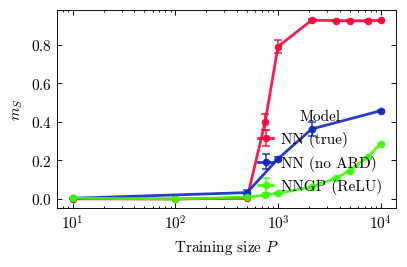

In [1]:
# mS_vs_P_three_sources.py
# Load (true NN from training_results.json) + (NN no-ARD) + (NNGP) for ONE kappa,
# then plot m_S vs P with **vertical error bars** (SEM) using your slim_plotters.py.
# Also prints mean±std of **test MSE** for each P so you can see scale when yerr is tiny.

from __future__ import annotations
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import sys, importlib.util

# ---------------- slim_plotters import (file or module) ----------------
def import_slim_plotters(slim_plotters_path: str | None = None):
    """
    Try to import `slim_plotters` as a normal module. If that fails:
      - If slim_plotters_path is a directory, use <dir>/slim_plotters.py
      - If it's a file, import exactly that file.
    Returns: (apply, color, SciencePlotter, PlotStyle)
    """
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        pass  # fallback below

    if slim_plotters_path is None:
        raise ModuleNotFoundError("No module named 'slim_plotters' and no slim_plotters_path provided.")

    p = Path(slim_plotters_path).expanduser().resolve()
    if p.is_dir():
        p = p / "slim_plotters.py"
    if not p.exists():
        raise FileNotFoundError(f"slim_plotters.py not found at: {p}")

    # easiest: add its folder to sys.path then import
    sys.path.insert(0, str(p.parent))
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        spec = importlib.util.spec_from_file_location("slim_plotters", str(p))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not load spec for: {p}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules["slim_plotters"] = mod
        return mod.apply, mod.color, mod.SciencePlotter, mod.PlotStyle


# ============================ utilities ================================
def _fmt_float_key(x: float, ndigits: int = 8) -> str:
    return f"{float(x):.{ndigits}f}"

def _flatten_once(x):
    out = []
    if isinstance(x, list):
        for t in x:
            if isinstance(t, list):
                out.extend(t)
            else:
                out.append(t)
    else:
        out = [x]
    return out

def _mS_scalar_from_vector(v: List[float]) -> float:
    """
    Turn (possibly multi-mode) vector into scalar:
      - if 1 value -> that value
      - if multiple -> L2 norm across modes (comparable scalar)
    """
    if v is None:
        return float('nan')
    flat = [float(u) for u in _flatten_once(v)]
    if len(flat) == 0:
        return float('nan')
    if len(flat) == 1:
        return float(flat[0])
    return float(np.linalg.norm(flat))

def _infer_P_from_name(name: str) -> Optional[int]:
    # handles ..._P1000_... or ..._Ptr1000_...
    import re
    m = re.search(r"_P(\d+)_", name)
    if m:
        return int(m.group(1))
    m = re.search(r"_Ptr(\d+)_", name)
    if m:
        return int(m.group(1))
    return None

def _to_xy(model_dict: Dict[int, Dict[str, float]]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Pull x=P, y=mS_mean, e=mS_sem arrays (sorted by P).
    """
    if not model_dict:
        return np.array([]), np.array([]), np.array([])
    P_sorted = sorted(model_dict.keys())
    x = np.array(P_sorted, dtype=float)
    y = np.array([model_dict[P]["mS_mean"] for P in P_sorted], dtype=float)
    e = np.array([model_dict[P]["mS_sem"]  for P in P_sorted], dtype=float)
    return x, y, e


# ======================== loaders: TRUE NN =============================
def build_summary_mse(results_path: str | Path,
                      kappa_ndigits: int = 8
                     ) -> Dict[int, Dict[str, Dict[int, Dict[str, float]]]]:
    """
    Replicates your notebook helper:
    summary[P][kappa_str][exp_id] = {"train_mse","test_mse","m_S"}
    """
    path = Path(results_path)
    with path.open("r") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError("Expected JSON list of records in training_results.json")
    summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]] = {}
    best_epochs: Dict[tuple, int] = {}
    for rec in data:
        P = int(rec["P"])
        kappa_key = _fmt_float_key(rec["kappa_0"], ndigits=kappa_ndigits)
        exp_id = int(rec["exp_id"])
        epochs_run = int(rec.get("epochs_run", -1))
        train_mse = float(rec["train_mse"])
        test_mse  = float(rec["test_mse"])
        if "final_eval_mS" in rec:
            m_s = float(rec["final_eval_mS"])
        elif "init_eval_mS" in rec:
            m_s = float(rec["init_eval_mS"])
        else:
            m_s = float("nan")
        key = (P, kappa_key, exp_id)
        if key in best_epochs and epochs_run <= best_epochs[key]:
            continue
        summary.setdefault(P, {}).setdefault(kappa_key, {})[exp_id] = {
            "train_mse": train_mse,
            "test_mse": test_mse,
            "m_S": m_s,
        }
        best_epochs[key] = epochs_run
    return summary

def agg_true_nn(summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]],
                kappa: float, kappa_ndigits: int = 8) -> Dict[int, Dict[str, float]]:
    """
    Aggregate ONE kappa across exp_id -> stats per P:
      returns { P: {"mS_mean","mS_sem","test_mean","test_std"} }
    """
    kkey = _fmt_float_key(kappa, ndigits=kappa_ndigits)
    out: Dict[int, Dict[str, float]] = {}
    for P, kappas in summary.items():
        if kkey not in kappas:
            continue
        exps = kappas[kkey]
        mS_arr   = np.array([float(v["m_S"])      for v in exps.values() if np.isfinite(v["m_S"])], dtype=float)
        test_arr = np.array([float(v["test_mse"]) for v in exps.values() if np.isfinite(v["test_mse"])], dtype=float)
        if mS_arr.size == 0:
            continue
        mS_mean = float(mS_arr.mean())
        mS_sem  = float(mS_arr.std(ddof=1)/np.sqrt(mS_arr.size)) if mS_arr.size > 1 else 0.0
        test_mean = float(test_arr.mean()) if test_arr.size else float("nan")
        test_std  = float(test_arr.std(ddof=1)) if test_arr.size > 1 else 0.0
        out[int(P)] = {"mS_mean": mS_mean, "mS_sem": mS_sem, "test_mean": test_mean, "test_std": test_std}
    return out


# ========================= loaders: NNGP ===============================
def load_nngp_one_kappa(nngp_dir: str | Path, kappa: float) -> Dict[int, Dict[str, float]]:
    """
    Scan a folder of NNGP JSONs and return {P: {"mS_mean","mS_sem","test_mean","test_std"}}
    Uses summary.final_eval.eval_mS_vec -> scalar via L2 magnitude across modes.
    If a test MSE is present (summary.final_eval.test_mse or summary.test_mse), include it (std=0).
    """
    root = Path(nngp_dir)
    files = sorted(root.glob("nngp_relu_composite_*.json"))
    out: Dict[int, Dict[str, float]] = {}
    for fp in files:
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        summ = obj.get("summary", {})
        k = float(summ.get("kappa", "nan"))
        if not np.isfinite(k) or abs(k - float(kappa)) > 1e-15:
            continue
        P = int(summ.get("P_train") or _infer_P_from_name(fp.name) or -1)
        if P < 0:
            continue
        final_eval = summ.get("final_eval", {})
        m_vec = final_eval.get("eval_mS_vec", [])
        m_scalar = _mS_scalar_from_vector(m_vec)
        # try to fetch a test MSE if available
        test_mse = None
        if "test_mse" in final_eval:
            test_mse = float(final_eval["test_mse"])
        elif "test_mse" in summ:
            test_mse = float(summ["test_mse"])
        out[P] = {
            "mS_mean": float(m_scalar),
            "mS_sem":  0.0,
            "test_mean": float(test_mse) if test_mse is not None else float("nan"),
            "test_std":  0.0 if test_mse is not None else 0.0,
        }
    return out


# ===================== loaders: NN (no-ARD / +ARD) ====================
def _choose_best_file_per_P(candidates: List[Path], kappa: float) -> Dict[int, Path]:
    """
    When multiple files exist for the same (P, κ), keep the one with lower test-MSE,
    tie-breaking on lower train-MSE. test-MSE ≈ 2 * last(traj.half_mse_empirical),
    with fallbacks to per-exp or test_mse_small.
    """
    best: Dict[int, Tuple[float, float, Path]] = {}  # P -> (test_mse, train_mse, path)
    for fp in candidates:
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        cfg = obj.get("config", {})
        k = float(cfg.get("kappa", "nan"))
        if not np.isfinite(k) or abs(k - float(kappa)) > 1e-15:
            continue
        P = _infer_P_from_name(fp.name)
        if P is None:
            continue

        traj = obj.get("traj", {})
        train = float(traj.get("train_mse", [float('inf')])[-1]) if traj.get("train_mse") else float('inf')

        # derive test mse
        if isinstance(traj.get("half_mse_empirical"), list) and traj["half_mse_empirical"]:
            test = 2.0 * float(traj["half_mse_empirical"][-1])
        elif isinstance(traj.get("half_mse_empirical_per_exp"), list) and traj["half_mse_empirical_per_exp"] and isinstance(traj["half_mse_empirical_per_exp"][-1], list):
            test = 2.0 * float(np.mean(traj["half_mse_empirical_per_exp"][-1]))
        else:
            test = float(traj.get("test_mse_small", [float('inf')])[-1])

        keep = False
        if P not in best:
            keep = True
        else:
            old_test, old_train, _ = best[P]
            if (test < old_test) or (math.isclose(test, old_test) and train < old_train):
                keep = True
        if keep:
            best[P] = (float(test), float(train), fp)
    return {P: path for P, (_, _, path) in best.items()}

def load_sgld_one_kappa(root_dir: str | Path, kappa: float) -> Dict[int, Dict[str, float]]:
    """
    Recursively scan root for rs_aw_ard_sgld_FAST_*.json with this κ.
    Choose best file per P. From the chosen file, compute per-exp stats at final step:
      - m_S: L2 across modes, then mean/SEM across E
      - test MSE: 2 * half_mse_empirical_per_exp (if available), then mean/std across E
    Returns { P: {"mS_mean","mS_sem","test_mean","test_std"} }.
    """
    root = Path(root_dir)
    files = list(root.rglob("rs_aw_ard_sgld_FAST_*.json"))
    chosen = _choose_best_file_per_P(files, kappa)

    results: Dict[int, Dict[str, float]] = {}
    for P, fp in chosen.items():
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        traj = obj.get("traj", {})

        # ---- m_S per-exp array (final)
        mS_per_exp = []
        mS_pe_list = traj.get("m_S_per_exp")
        if isinstance(mS_pe_list, list) and mS_pe_list and isinstance(mS_pe_list[-1], list):
            for exp_item in mS_pe_list[-1]:
                flat = [float(u) for u in _flatten_once(exp_item)]
                if len(flat) == 0:
                    mS_per_exp.append(float('nan'))
                elif len(flat) == 1:
                    mS_per_exp.append(float(flat[0]))
                else:
                    mS_per_exp.append(float(np.linalg.norm(flat)))
        else:
            # fallback to aggregate m_S (vector) -> scalar
            mS_vec_list = traj.get("m_S", [])
            mS_scalar = _mS_scalar_from_vector(mS_vec_list[-1]) if mS_vec_list else float('nan')
            mS_per_exp = [mS_scalar]

        mS_arr = np.array([v for v in mS_per_exp if np.isfinite(v)], dtype=float)
        if mS_arr.size > 0:
            mS_mean = float(mS_arr.mean())
            mS_sem  = float(mS_arr.std(ddof=1) / np.sqrt(mS_arr.size)) if mS_arr.size > 1 else 0.0
        else:
            mS_mean, mS_sem = float('nan'), float('nan')

        # ---- test MSE per-exp (if available)
        test_arr = None
        hmse_pe = traj.get("half_mse_empirical_per_exp")
        if isinstance(hmse_pe, list) and hmse_pe and isinstance(hmse_pe[-1], list):
            test_arr = 2.0 * np.array([float(x) for x in hmse_pe[-1]], dtype=float)
        elif isinstance(traj.get("half_mse_empirical"), list) and traj["half_mse_empirical"]:
            test_arr = np.array([2.0 * float(traj["half_mse_empirical"][-1])], dtype=float)
        elif isinstance(traj.get("test_mse_small"), list) and traj["test_mse_small"]:
            test_arr = np.array([float(traj["test_mse_small"][-1])], dtype=float)

        if test_arr is not None and test_arr.size:
            test_mean = float(np.nanmean(test_arr))
            test_std  = float(np.nanstd(test_arr, ddof=1)) if test_arr.size > 1 else 0.0
        else:
            test_mean, test_std = float('nan'), 0.0

        results[int(P)] = {"mS_mean": mS_mean, "mS_sem": mS_sem, "test_mean": test_mean, "test_std": test_std}
    return results


# ============================== plotting ===============================
def _normalize_color(c):
    """
    Accept hex '#RRGGBB', RGB tuple in [0,1] or [0,255], or named mpl color.
    Returns something matplotlib can use.
    """
    if isinstance(c, tuple) and len(c) == 3:
        # if looks like 0-255, scale; else pass-through
        if max(c) > 1.0:
            return tuple([v/255.0 for v in c])
        return c
    return c  # hex or name

def _print_series_stats(label: str, series: Dict[int, Dict[str, float]]):
    if not series:
        print(f"[{label}] (no data)")
        return
    print(f"\n[{label}]  P  |  m_S(mean±SEM)   |   test MSE (mean±std)")
    for P in sorted(series.keys()):
        s = series[P]
        mS_mean  = s.get("mS_mean", float('nan'))
        mS_sem   = s.get("mS_sem",  float('nan'))
        t_mean   = s.get("test_mean", float('nan'))
        t_std    = s.get("test_std",  0.0)
        print(f"  P={P:<6d}  {mS_mean:.6g} ± {mS_sem:.6g}    |    {t_mean:.6g} ± {t_std:.6g}")

def plot_mS_vs_P_with_errorbars(
    *,
    kappa: float,
    true_nn_results_json: str | Path,
    sgld_noard_root: str | Path,
    nngp_dir: str | Path,
    slim_plotters_path: Optional[str] = None,   # set if slim_plotters.py isn't importable
    theme: str = "light",
    # ----- layout controls -----
    fig_width: float = 3.6,
    aspect: float = 1.35,          # width / height
    ylog: bool = False,
    # ----- legend & labels -----
    legend_loc: str = "lower right",
    legend_title: Optional[str] = None,
    xlabel: str = r"Training size $P$",
    ylabel: str = r"$m_S$",
    title: Optional[str] = None,   # None => no title
    # ----- color controls (hex or RGB) -----
    color_true_nn = "#FFB463",     # orange
    color_no_ard  = "#d1001d",     # red
    color_nngp    = "#01B5EB",     # blue
    # ----- errorbar style -----
    capsize: float = 2.5,
    elinewidth: float = 1.0,
    ealpha: float = 0.9,
    markersize: float = 4.0,
    linewidth: float = 1.8,
    # ----- print stats -----
    print_stats: bool = True,
):
    # import style & apply theme
    apply, color, SciencePlotter, PlotStyle = import_slim_plotters(slim_plotters_path)
    apply(theme=theme)

    # 1) TRUE NN
    nn_summary = build_summary_mse(true_nn_results_json)
    nn_true = agg_true_nn(nn_summary, kappa=kappa)

    # 2) NN no-ARD (SGLD)
    nn_noard = load_sgld_one_kappa(sgld_noard_root, kappa)

    # 3) NNGP
    nngp = load_nngp_one_kappa(nngp_dir, kappa)

    # optionally print stats to console
    if print_stats:
        print(f"\n=== κ = {kappa:g} ===")
        _print_series_stats("NN (true)",    nn_true)
        _print_series_stats("NN (no ARD)",  nn_noard)
        _print_series_stats("NNGP (ReLU)",  nngp)

    # arrays
    x1, y1, e1 = _to_xy(nn_true)
    x2, y2, e2 = _to_xy(nn_noard)
    x3, y3, e3 = _to_xy(nngp)

    # figure size from width & aspect
    fig_h = max(1e-6, fig_width / float(aspect))
    fig, ax = plt.subplots(figsize=(fig_width, fig_h))

    # prepare colors
    c1 = _normalize_color(color_true_nn)
    c2 = _normalize_color(color_no_ard)
    c3 = _normalize_color(color_nngp)

    # plot with **vertical** error bars only (yerr)
    if x1.size:
        ax.errorbar(x1, y1, yerr=e1, fmt='o-', color=c1, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label="NN (true)", zorder=3)
    if x2.size:
        ax.errorbar(x2, y2, yerr=e2, fmt='o-', color=c2, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label="NN (no ARD)", zorder=3)
    if x3.size:
        ax.errorbar(x3, y3, yerr=e3, fmt='o-', color=c3, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label="NNGP (ReLU)", zorder=3)

    # axes
    ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # legend
    leg = ax.legend(loc=legend_loc, frameon=False)
    if legend_title is not None and leg is not None:
        leg.set_title(legend_title)

    # optional title (off by default)
    if title:
        ax.set_title(title, pad=6)

    ax.grid(False)
    plt.tight_layout()
    return fig, {"nn_true": nn_true, "nn_noard": nn_noard, "nngp": nngp}


# ============================ example usage ============================
if __name__ == "__main__":
    SLIM_PLOTTERS_FILE = "/home/goring/mean_field_langevin/plots_utils/slim_plotters.py"  # or None if importable

    KAPPA = 5e-3
    TRUE_NN_RESULTS = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/training_results.json"
    
    #NO_ARD_ROOT     = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard"
    NO_ARD_ROOT ="/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix"
    NNGP_DIR        = "/home/goring/mean_field_langevin/MCMC_composite/results_NNGP/d35_k4_5e-3_paper"

    # Customize layout, legend, and colors here:
    fig, data = plot_mS_vs_P_with_errorbars(
        kappa=KAPPA,
        true_nn_results_json=TRUE_NN_RESULTS,
        sgld_noard_root=NO_ARD_ROOT,
        nngp_dir=NNGP_DIR,
        slim_plotters_path=SLIM_PLOTTERS_FILE,   # set to the file if import fails
        theme="light",
        # layout
        fig_width=3.8,
        aspect=1.5,            # width / height ; e.g., 1.5 makes it wider
        ylog=False,
        # legend
        legend_loc="lower right",
        legend_title="Model",
        # custom colors (hex or RGB tuples)
        color_true_nn="#FD0139",     # orange
        color_no_ard  ="#0E26C4", # red as RGB 0-255
        color_nngp    ="#39FD01",    # blue
        # errorbar style
        capsize=2.5,
        elinewidth=1.0,
        ealpha=0.9,
        markersize=4.0,
        linewidth=1.8,
        # print per-P MSE stats to stdout
        print_stats=True,
        # labels
        xlabel=r"Training size $P$",
        ylabel=r"$m_S$",
        title=None,  # keep no title (set a string if you want one)
    )

    out_path = f"mS_vs_P_kappa_{KAPPA:g}_errbars.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"\n[saved] {out_path}")
    plt.show()



=== κ = 0.005 ===

[NN (true)]  P  |   Test MSE (mean±std)   |   n
  P=10      1.53225 ± 0.0820451    |   3
  P=100     1.50779 ± 0.0630611    |   3
  P=500     1.66593 ± 0.0147756    |   3
  P=750     0.815104 ± 0.205148    |   3
  P=1000    0.135888 ± 0.0463404    |   3
  P=2133    0.0368448 ± 0.00319517    |   3
  P=3666    0.0331048 ± 0.0015972    |   3
  P=5000    0.0297727 ± 0.00236052    |   3
  P=7500    0.0288063 ± 0.00112934    |   3
  P=10000   0.0275001 ± 0.00113557    |   3

[NN (no ARD)]  P  |   Test MSE (mean±std)   |   n
  P=10      1.4544 ± 0.101274    |   3
  P=500     1.26098 ± 0.0487655    |   3
  P=1000    0.733939 ± 0.0340188    |   3
  P=2133    0.430844 ± 0.09065    |   3
  P=3666    0.518551 ± 0.0194207    |   3
  P=10000   0.306048 ± 0.0128522    |   3

[NNGP (ReLU)]  P  |   Test MSE (mean±std)   |   n
  P=10      nan ± 0    |   0
  P=100     nan ± 0    |   0
  P=500     nan ± 0    |   0
  P=750     nan ± 0    |   0
  P=1000    nan ± 0    |   0
  P=2133    na

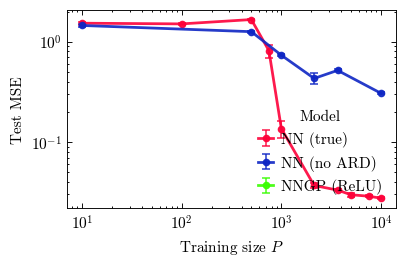

In [3]:
# testMSE_vs_P_three_sources.py
# Load (true NN from training_results.json) + (NN no-ARD) + (NNGP) for ONE kappa,
# then plot Test MSE vs P with **vertical error bars** (SEM) using your slim_plotters.py.
# Also prints mean±std of **test MSE** for each P so you can see scale when yerr is tiny.

from __future__ import annotations
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import sys, importlib.util

# ---------------- slim_plotters import (file or module) ----------------
def import_slim_plotters(slim_plotters_path: str | None = None):
    """
    Try to import `slim_plotters` as a normal module. If that fails:
      - If slim_plotters_path is a directory, use <dir>/slim_plotters.py
      - If it's a file, import exactly that file.
    Returns: (apply, color, SciencePlotter, PlotStyle)
    """
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        pass  # fallback below

    if slim_plotters_path is None:
        raise ModuleNotFoundError("No module named 'slim_plotters' and no slim_plotters_path provided.")

    p = Path(slim_plotters_path).expanduser().resolve()
    if p.is_dir():
        p = p / "slim_plotters.py"
    if not p.exists():
        raise FileNotFoundError(f"slim_plotters.py not found at: {p}")

    # easiest: add its folder to sys.path then import
    sys.path.insert(0, str(p.parent))
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        spec = importlib.util.spec_from_file_location("slim_plotters", str(p))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not load spec for: {p}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules["slim_plotters"] = mod
        return mod.apply, mod.color, mod.SciencePlotter, mod.PlotStyle


# ============================ utilities ================================
def _fmt_float_key(x: float, ndigits: int = 8) -> str:
    return f"{float(x):.{ndigits}f}"

def _flatten_once(x):
    out = []
    if isinstance(x, list):
        for t in x:
            if isinstance(t, list):
                out.extend(t)
            else:
                out.append(t)
    else:
        out = [x]
    return out

def _mS_scalar_from_vector(v: List[float]) -> float:
    """
    Turn (possibly multi-mode) vector into scalar:
      - if 1 value -> that value
      - if multiple -> L2 norm across modes (comparable scalar)
    """
    if v is None:
        return float('nan')
    flat = [float(u) for u in _flatten_once(v)]
    if len(flat) == 0:
        return float('nan')
    if len(flat) == 1:
        return float(flat[0])
    return float(np.linalg.norm(flat))

def _infer_P_from_name(name: str) -> Optional[int]:
    # handles ..._P1000_... or ..._Ptr1000_...
    import re
    m = re.search(r"_P(\d+)_", name)
    if m:
        return int(m.group(1))
    m = re.search(r"_Ptr(\d+)_", name)
    if m:
        return int(m.group(1))
    return None

def _to_xy_keys(model_dict: Dict[int, Dict[str, float]],
                mean_key: str,
                sem_key: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generic pull x=P, y=<mean_key>, e=<sem_key> arrays (sorted by P).
    """
    if not model_dict:
        return np.array([]), np.array([]), np.array([])
    P_sorted = sorted(model_dict.keys())
    x = np.array(P_sorted, dtype=float)
    y = np.array([model_dict[P].get(mean_key, np.nan) for P in P_sorted], dtype=float)
    e = np.array([model_dict[P].get(sem_key,  np.nan) for P in P_sorted], dtype=float)
    return x, y, e


# ======================== loaders: TRUE NN =============================
def build_summary_mse(results_path: str | Path,
                      kappa_ndigits: int = 8
                     ) -> Dict[int, Dict[str, Dict[int, Dict[str, float]]]]:
    """
    Replicates your notebook helper:
    summary[P][kappa_str][exp_id] = {"train_mse","test_mse","m_S"}
    """
    path = Path(results_path)
    with path.open("r") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError("Expected JSON list of records in training_results.json")
    summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]] = {}
    best_epochs: Dict[tuple, int] = {}
    for rec in data:
        P = int(rec["P"])
        kappa_key = _fmt_float_key(rec["kappa_0"], ndigits=kappa_ndigits)
        exp_id = int(rec["exp_id"])
        epochs_run = int(rec.get("epochs_run", -1))
        train_mse = float(rec["train_mse"])
        test_mse  = float(rec["test_mse"])
        if "final_eval_mS" in rec:
            m_s = float(rec["final_eval_mS"])
        elif "init_eval_mS" in rec:
            m_s = float(rec["init_eval_mS"])
        else:
            m_s = float("nan")
        key = (P, kappa_key, exp_id)
        if key in best_epochs and epochs_run <= best_epochs[key]:
            continue
        summary.setdefault(P, {}).setdefault(kappa_key, {})[exp_id] = {
            "train_mse": train_mse,
            "test_mse": test_mse,
            "m_S": m_s,
        }
        best_epochs[key] = epochs_run
    return summary

def agg_true_nn(summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]],
                kappa: float, kappa_ndigits: int = 8) -> Dict[int, Dict[str, float]]:
    """
    Aggregate ONE kappa across exp_id -> stats per P:
      returns {
        P: {
          "mS_mean","mS_sem",
          "test_mean","test_std","test_sem","n_exp"
        }
      }
    """
    kkey = _fmt_float_key(kappa, ndigits=kappa_ndigits)
    out: Dict[int, Dict[str, float]] = {}
    for P, kappas in summary.items():
        if kkey not in kappas:
            continue
        exps = kappas[kkey]
        mS_arr   = np.array([float(v["m_S"])      for v in exps.values() if np.isfinite(v["m_S"])], dtype=float)
        test_arr = np.array([float(v["test_mse"]) for v in exps.values() if np.isfinite(v["test_mse"])], dtype=float)

        if mS_arr.size == 0 and test_arr.size == 0:
            continue

        # m_S stats (kept for parity)
        if mS_arr.size:
            mS_mean = float(mS_arr.mean())
            mS_sem  = float(mS_arr.std(ddof=1)/np.sqrt(mS_arr.size)) if mS_arr.size > 1 else 0.0
        else:
            mS_mean, mS_sem = float("nan"), float("nan")

        # test mse stats
        if test_arr.size:
            t_mean = float(test_arr.mean())
            t_std  = float(test_arr.std(ddof=1)) if test_arr.size > 1 else 0.0
            t_sem  = float(t_std/np.sqrt(test_arr.size)) if test_arr.size > 1 else 0.0
            n_exp  = int(test_arr.size)
        else:
            t_mean, t_std, t_sem, n_exp = float("nan"), 0.0, float("nan"), 0

        out[int(P)] = {
            "mS_mean": mS_mean, "mS_sem": mS_sem,
            "test_mean": t_mean, "test_std": t_std, "test_sem": t_sem,
            "n_exp": n_exp
        }
    return out


# ========================= loaders: NNGP ===============================
def load_nngp_one_kappa(nngp_dir: str | Path, kappa: float) -> Dict[int, Dict[str, float]]:
    """
    Scan a folder of NNGP JSONs and return {P: {"mS_mean","mS_sem","test_mean","test_std","test_sem","n_exp"}}
    Uses summary.final_eval.eval_mS_vec -> scalar via L2 magnitude across modes.
    If a test MSE is present (summary.final_eval.test_mse or summary.test_mse), include it.
    """
    root = Path(nngp_dir)
    files = sorted(root.glob("nngp_relu_composite_*.json"))
    out: Dict[int, Dict[str, float]] = {}
    for fp in files:
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        summ = obj.get("summary", {})
        k = float(summ.get("kappa", "nan"))
        if not np.isfinite(k) or abs(k - float(kappa)) > 1e-15:
            continue
        P = int(summ.get("P_train") or _infer_P_from_name(fp.name) or -1)
        if P < 0:
            continue
        final_eval = summ.get("final_eval", {})
        m_vec = final_eval.get("eval_mS_vec", [])
        m_scalar = _mS_scalar_from_vector(m_vec)
        # test MSE if available (single value in most NNGP dumps)
        test_mse = None
        if "test_mse" in final_eval:
            test_mse = float(final_eval["test_mse"])
        elif "test_mse" in summ:
            test_mse = float(summ["test_mse"])
        out[P] = {
            "mS_mean": float(m_scalar),
            "mS_sem":  0.0,
            "test_mean": float(test_mse) if test_mse is not None else float("nan"),
            "test_std":  0.0 if test_mse is not None else 0.0,
            "test_sem":  0.0 if test_mse is not None else float("nan"),
            "n_exp":     1 if test_mse is not None else 0,
        }
    return out


# ===================== loaders: NN (no-ARD / +ARD) ====================
def _choose_best_file_per_P(candidates: List[Path], kappa: float) -> Dict[int, Path]:
    """
    When multiple files exist for the same (P, κ), keep the one with lower test-MSE,
    tie-breaking on lower train-MSE. test-MSE ≈ 2 * last(traj.half_mse_empirical),
    with fallbacks to per-exp or test_mse_small.
    """
    best: Dict[int, Tuple[float, float, Path]] = {}  # P -> (test_mse, train_mse, path)
    for fp in candidates:
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        cfg = obj.get("config", {})
        k = float(cfg.get("kappa", "nan"))
        if not np.isfinite(k) or abs(k - float(kappa)) > 1e-15:
            continue
        P = _infer_P_from_name(fp.name)
        if P is None:
            continue

        traj = obj.get("traj", {})
        train = float(traj.get("train_mse", [float('inf')])[-1]) if traj.get("train_mse") else float('inf')

        # derive test mse
        if isinstance(traj.get("half_mse_empirical"), list) and traj["half_mse_empirical"]:
            test = 2.0 * float(traj["half_mse_empirical"][-1])
        elif isinstance(traj.get("half_mse_empirical_per_exp"), list) and traj["half_mse_empirical_per_exp"] and isinstance(traj["half_mse_empirical_per_exp"][-1], list):
            test = 2.0 * float(np.mean(traj["half_mse_empirical_per_exp"][-1]))
        else:
            test = float(traj.get("test_mse_small", [float('inf')])[-1])

        keep = False
        if P not in best:
            keep = True
        else:
            old_test, old_train, _ = best[P]
            if (test < old_test) or (math.isclose(test, old_test) and train < old_train):
                keep = True
        if keep:
            best[P] = (float(test), float(train), fp)
    return {P: path for P, (_, _, path) in best.items()}

def load_sgld_one_kappa(root_dir: str | Path, kappa: float) -> Dict[int, Dict[str, float]]:
    """
    Recursively scan root for rs_aw_ard_sgld_FAST_*.json with this κ.
    Choose best file per P. From the chosen file, compute per-exp stats at final step:
      - m_S: L2 across modes, then mean/SEM across E (kept for parity)
      - test MSE: 2 * half_mse_empirical_per_exp (if available), then mean/std/SEM across E
    Returns { P: {"mS_mean","mS_sem","test_mean","test_std","test_sem","n_exp"} }.
    """
    root = Path(root_dir)
    files = list(root.rglob("rs_aw_ard_sgld_FAST_*.json"))
    chosen = _choose_best_file_per_P(files, kappa)

    results: Dict[int, Dict[str, float]] = {}
    for P, fp in chosen.items():
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        traj = obj.get("traj", {})

        # ---- m_S per-exp array (final, optional)
        mS_per_exp = []
        mS_pe_list = traj.get("m_S_per_exp")
        if isinstance(mS_pe_list, list) and mS_pe_list and isinstance(mS_pe_list[-1], list):
            for exp_item in mS_pe_list[-1]:
                flat = [float(u) for u in _flatten_once(exp_item)]
                if len(flat) == 0:
                    mS_per_exp.append(float('nan'))
                elif len(flat) == 1:
                    mS_per_exp.append(float(flat[0]))
                else:
                    mS_per_exp.append(float(np.linalg.norm(flat)))
        else:
            mS_vec_list = traj.get("m_S", [])
            mS_scalar = _mS_scalar_from_vector(mS_vec_list[-1]) if mS_vec_list else float('nan')
            mS_per_exp = [mS_scalar]

        mS_arr = np.array([v for v in mS_per_exp if np.isfinite(v)], dtype=float)
        if mS_arr.size > 0:
            mS_mean = float(mS_arr.mean())
            mS_sem  = float(mS_arr.std(ddof=1) / np.sqrt(mS_arr.size)) if mS_arr.size > 1 else 0.0
        else:
            mS_mean, mS_sem = float('nan'), float('nan')

        # ---- test MSE per-exp (if available)
        test_arr = None
        hmse_pe = traj.get("half_mse_empirical_per_exp")
        if isinstance(hmse_pe, list) and hmse_pe and isinstance(hmse_pe[-1], list):
            test_arr = 2.0 * np.array([float(x) for x in hmse_pe[-1]], dtype=float)
        elif isinstance(traj.get("half_mse_empirical"), list) and traj["half_mse_empirical"]:
            test_arr = np.array([2.0 * float(traj["half_mse_empirical"][-1])], dtype=float)
        elif isinstance(traj.get("test_mse_small"), list) and traj["test_mse_small"]:
            test_arr = np.array([float(traj["test_mse_small"][-1])], dtype=float)

        if test_arr is not None and test_arr.size:
            test_arr = test_arr[np.isfinite(test_arr)]
            n_exp = int(test_arr.size)
            test_mean = float(np.nanmean(test_arr)) if n_exp else float('nan')
            test_std  = float(np.nanstd(test_arr, ddof=1)) if n_exp > 1 else 0.0
            test_sem  = float(test_std/np.sqrt(n_exp)) if n_exp > 1 else 0.0
        else:
            test_mean, test_std, test_sem, n_exp = float('nan'), 0.0, float('nan'), 0

        results[int(P)] = {
            "mS_mean": mS_mean, "mS_sem": mS_sem,
            "test_mean": test_mean, "test_std": test_std, "test_sem": test_sem,
            "n_exp": n_exp
        }
    return results


# ============================== printing ===============================
def _print_series_stats(label: str, series: Dict[int, Dict[str, float]]):
    if not series:
        print(f"[{label}] (no data)")
        return
    print(f"\n[{label}]  P  |   Test MSE (mean±std)   |   n")
    for P in sorted(series.keys()):
        s = series[P]
        t_mean = s.get("test_mean", float('nan'))
        t_std  = s.get("test_std",  0.0)
        n_exp  = int(s.get("n_exp", 0))
        print(f"  P={P:<6d}  {t_mean:.6g} ± {t_std:.6g}    |   {n_exp}")


# ============================== plotting ===============================
def _normalize_color(c):
    """
    Accept hex '#RRGGBB', RGB tuple in [0,1] or [0,255], or named mpl color.
    Returns something matplotlib can use.
    """
    if isinstance(c, tuple) and len(c) == 3:
        if max(c) > 1.0:
            return tuple([v/255.0 for v in c])
        return c
    return c  # hex or name

def plot_testMSE_vs_P_with_errorbars(
    *,
    kappa: float,
    true_nn_results_json: str | Path,
    sgld_noard_root: str | Path,
    nngp_dir: str | Path,
    slim_plotters_path: Optional[str] = None,   # set if slim_plotters.py isn't importable
    theme: str = "light",
    # ----- layout controls -----
    fig_width: float = 3.6,
    aspect: float = 1.35,          # width / height
    ylog: bool = False,
    # ----- legend & labels -----
    legend_loc: str = "lower right",
    legend_title: Optional[str] = None,
    xlabel: str = r"Training size $P$",
    ylabel: str = r"Test MSE",
    title: Optional[str] = None,   # None => no title
    # ----- color controls (hex or RGB) -----
    color_true_nn = "#FFB463",     # orange
    color_no_ard  = "#d1001d",     # red
    color_nngp    = "#01B5EB",     # blue
    # ----- errorbar style -----
    capsize: float = 2.5,
    elinewidth: float = 1.0,
    ealpha: float = 0.9,
    markersize: float = 4.0,
    linewidth: float = 1.8,
    # ----- print stats -----
    print_stats: bool = True,
):
    # import style & apply theme
    apply, color, SciencePlotter, PlotStyle = import_slim_plotters(slim_plotters_path)
    apply(theme=theme)

    # 1) TRUE NN
    nn_summary = build_summary_mse(true_nn_results_json)
    nn_true = agg_true_nn(nn_summary, kappa=kappa)

    # 2) NN no-ARD (SGLD)
    nn_noard = load_sgld_one_kappa(sgld_noard_root, kappa)

    # 3) NNGP
    nngp = load_nngp_one_kappa(nngp_dir, kappa)

    # optionally print stats to console (mean±std; error bars use SEM)
    if print_stats:
        print(f"\n=== κ = {kappa:g} ===")
        _print_series_stats("NN (true)",    nn_true)
        _print_series_stats("NN (no ARD)",  nn_noard)
        _print_series_stats("NNGP (ReLU)",  nngp)

    # arrays (use mean=test_mean, err=test_sem)
    x1, y1, e1 = _to_xy_keys(nn_true,  mean_key="test_mean", sem_key="test_sem")
    x2, y2, e2 = _to_xy_keys(nn_noard, mean_key="test_mean", sem_key="test_sem")
    x3, y3, e3 = _to_xy_keys(nngp,     mean_key="test_mean", sem_key="test_sem")

    # figure size from width & aspect
    fig_h = max(1e-6, fig_width / float(aspect))
    fig, ax = plt.subplots(figsize=(fig_width, fig_h))

    # prepare colors
    c1 = _normalize_color(color_true_nn)
    c2 = _normalize_color(color_no_ard)
    c3 = _normalize_color(color_nngp)

    # plot with **vertical** error bars only (SEM on test MSE)
    if x1.size:
        ax.errorbar(x1, y1, yerr=e1, fmt='o-', color=c1, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label="NN (true)", zorder=3)
    if x2.size:
        ax.errorbar(x2, y2, yerr=e2, fmt='o-', color=c2, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label="NN (no ARD)", zorder=3)
    if x3.size:
        ax.errorbar(x3, y3, yerr=e3, fmt='o-', color=c3, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label="NNGP (ReLU)", zorder=3)

    # axes
    ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # legend
    leg = ax.legend(loc=legend_loc, frameon=False)
    if legend_title is not None and leg is not None:
        leg.set_title(legend_title)

    # optional title (off by default)
    if title:
        ax.set_title(title, pad=6)

    ax.grid(False)
    plt.tight_layout()
    return fig, {"nn_true": nn_true, "nn_noard": nn_noard, "nngp": nngp}


# ============================ example usage ============================
if __name__ == "__main__":
    SLIM_PLOTTERS_FILE = "/home/goring/mean_field_langevin/plots_utils/slim_plotters.py"  # or None if importable

    KAPPA = 5e-3
    TRUE_NN_RESULTS = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/training_results.json"
    
    #NO_ARD_ROOT     = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard"
    NO_ARD_ROOT ="/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix"
    NNGP_DIR        = "/home/goring/mean_field_langevin/MCMC_composite/results_NNGP/d35_k4_5e-3_paper"

    # Customize layout, legend, and colors here:
    fig, data = plot_testMSE_vs_P_with_errorbars(
        kappa=KAPPA,
        true_nn_results_json=TRUE_NN_RESULTS,
        sgld_noard_root=NO_ARD_ROOT,
        nngp_dir=NNGP_DIR,
        slim_plotters_path=SLIM_PLOTTERS_FILE,   # set to the file if import fails
        theme="light",
        # layout
        fig_width=3.8,
        aspect=1.5,            # width / height ; e.g., 1.5 makes it wider
        ylog=True,            # set True if your MSE spans orders of magnitude
        # legend
        legend_loc="lower right",
        legend_title="Model",
        # custom colors (hex or RGB tuples)
        color_true_nn="#FD0139",
        color_no_ard  ="#0E26C4",
        color_nngp    ="#39FD01",
        # errorbar style
        capsize=2.5,
        elinewidth=1.0,
        ealpha=0.9,
        markersize=4.0,
        linewidth=1.8,
        # print per-P MSE stats to stdout (mean±std)
        print_stats=True,
        # labels
        xlabel=r"Training size $P$",
        ylabel=r"Test MSE",
        title=None,
    )

    out_path = f"testMSE_vs_P_kappa_{KAPPA:g}_errbars.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"\n[saved] {out_path}")
    plt.show()
